In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
visa_data=pd.read_csv(r"C:\Users\Suman\Documents\Naresh IT\data files\Visadataset.csv")
num=visa_data.select_dtypes(exclude='object').columns
cat=visa_data.select_dtypes(include='object').columns

In [3]:
visa_data['prevailing_wage']

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

**why scaling**
- **scaling preserves the numerical stability across the column**
  - Ex: age : 20   salary: 50000   exp: 2
  - different column s having the different scale(limit)
  - we want to keep all the columns under same limit
  - if we dont keep under same scale some Ml algo feels salary is the important column
    - because of the highest value
- **faster training**
  - some of ML algorithms like **KNN,Kmeans,SVM** are distance based algoriths
  - if we lower the values the calculations are fast
  - In every Model Development will do math calculations
  - In order to increase the fastness (optimization) scaling is very helpful

## Zscale ( also called as Standard Scaller)

<img alt="Z Score - An overview with examples - The Data School" id="dimg_D6h6aoPuEd23hvcPmoCMkAk_67" src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRbaJ18b_VyfysMDpB4AhCUXF_HRf6adXkzJ00SqfEsBQ&amp;s=10" data-csiid="D6h6aoPuEd23hvcPmoCMkAk_18" data-atf="5">

- z lies between 3 to -3
- according to empirical rule  

In [25]:
wage_data=visa_data['prevailing_wage']
# step1: wage_mean=wage_data.mean()
# step2: wage_sd
# step3: Nr=wage_date-wage_mean
# step4: Nr/wage_sd


wage_mean=wage_data.mean()
wage_sd=wage_data.std()
Nr=wage_data-wage_mean
wage_z=Nr/wage_sd
wage_z

0       -1.398510
1        0.169832
2        0.919060
3        0.169991
4        1.428576
           ...   
25475    0.049923
25476    3.876083
25477    1.360253
25478    0.221504
25479   -0.067762
Name: prevailing_wage, Length: 25480, dtype: float64

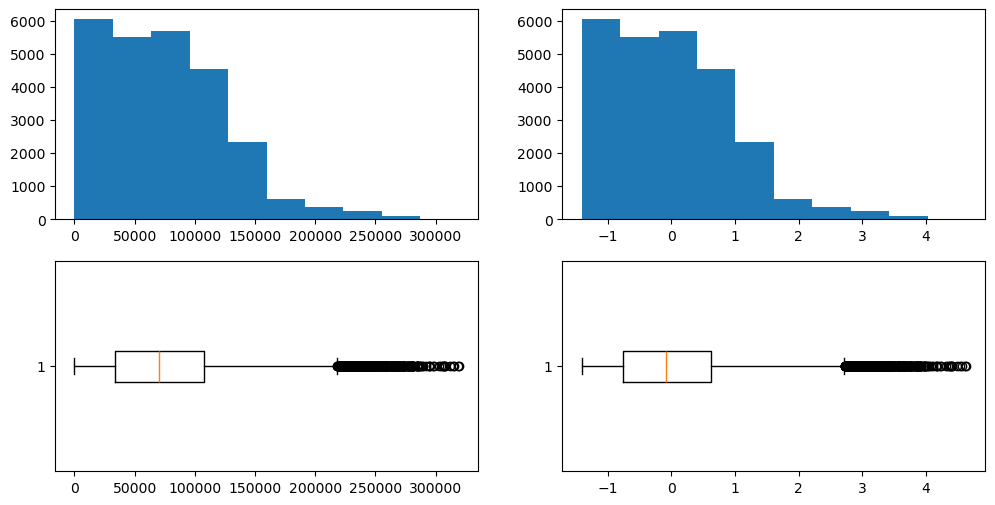

In [26]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(wage_z)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(wage_z,vert=False)
plt.show()

- sklearn
    - preprocessing
        - standard scaling
          - fit transform

In [30]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
wage_s=st.fit_transform([wage_data])
wage_s


array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 25480))

## MinMaxScaler  ( also called as Normalization)

<img alt="How Min-Max Scaler Works. The math behind the min-max scaler | by Kamlesh Kumar Rangi | Medium" id="dimg_4q96arzXGJCPseMPrfPGiQQ_57" src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQGFtEiEU1_NssKXFJo7ksfxoSonpu4QhzaR_IjBpPHyw&amp;s=10" data-csiid="4q96arzXGJCPseMPrfPGiQQ_5" data-atf="1">

In [9]:
# step-1: wage_min
# step-2: wage_max
# step-3: Nr=wage_data-wage_min
# step-4: Dr=wage_max-wage_min
# step-5: wage_norm=Nr/Dr


wage_data=visa_data['prevailing_wage']
wage_min=wage_data.min()
wage_max=wage_data.max()
Nr=wage_data-wage_min
Dr=wage_max-wage_min
wage_norm=Nr/Dr
wage_norm

0        0.001849
1        0.261345
2        0.385312
3        0.261371
4        0.469616
           ...   
25475    0.241505
25476    0.874579
25477    0.458311
25478    0.269895
25479    0.222033
Name: prevailing_wage, Length: 25480, dtype: float64

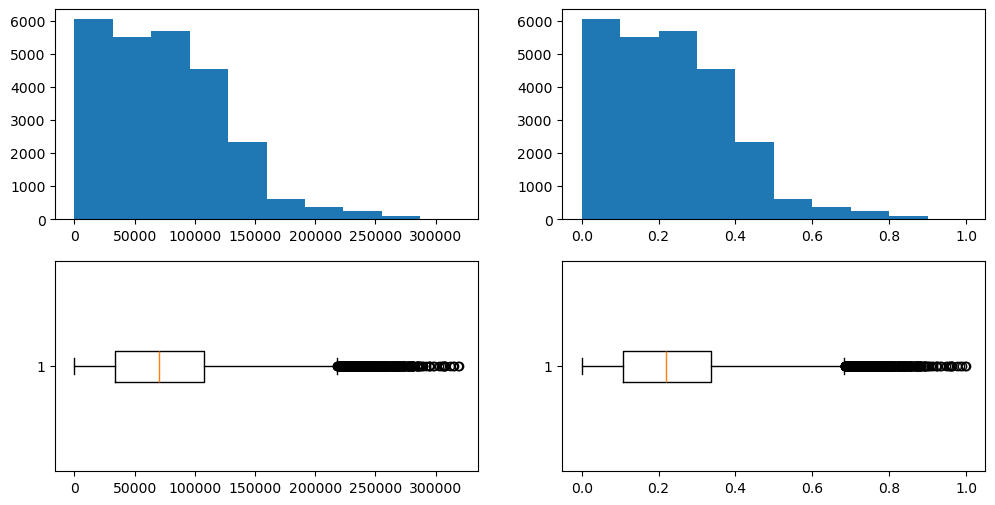

In [10]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(wage_norm)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(wage_norm,vert=False)
plt.show()

In [34]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
wage_mms=mms.fit_transform([wage_data])
wage_mms

array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 25480))